## Settup environment

In [ ]:
# Setup the environment
import pandas as pd

# Import the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%capture
!pip install bertopic

## Import dataset, clean the dataset

In [ ]:
print(data.head())

              PLACEKEY                                             Review  \
0  236-222@627-s86-k75  Great content. I was actually referred to this...   
1  236-222@627-s86-k75   Awesome and I look forward to working  with  you   
2  236-222@627-s86-k75        One of the greatest magazines in the world.   
3  236-222@627-s86-k75                                        Looks great   
4  236-222@627-s86-k75  Private residence.  It would be rude to knock ...   

             Timestamp  
0  2021-07-21 23:57:09  
1  2021-08-11 15:16:58  
2  2021-08-29 16:49:49  
3  2023-07-12 12:44:14  
4  2017-08-29 08:21:39  


In [ ]:

import pandas as pd
file_path = ''

pattern = r'\[(.*?)\],\[(.*?)\]' # 这个数据集每个rows的列不一样，对齐不了是读不了的

In [ ]:
import re
with open(file_path, 'r', encoding='utf-8') as file:
    for line in file:
        # Extract PLACEKEY and content
        split_line = line.split(',', 2)  # Split only on the first two commas to preserve review data format
        if len(split_line) < 3:
            continue  # Skip lines that do not contain enough data

        placekey = split_line[0]
        content = split_line[2]

        # Find all review and timestamp matches
        matches = re.findall(pattern, content)
        for match in matches:
            placekeys.append(placekey)
            reviews.append(match[0])
            timestamps.append(pd.to_datetime(match[1], errors='coerce'))

In [ ]:
# Creating DataFrame
data = pd.DataFrame({
    'PLACEKEY': placekeys,
    'Review': reviews,
    'Timestamp': timestamps
})

print(data.head())

              PLACEKEY                                             Review  \
0  226-222@5yv-jbv-k9f  Joseph has helped my husband and I to achieve ...   
1  226-222@5yv-jbv-k9f  Joey is pretty unique when it comes to Financi...   
2  226-222@5yv-jbv-k9f  I’ve worked with Joey now for a little bit ove...   
3  226-222@5yv-jbv-k9f  Joseph helped me understand both disability in...   
4  226-222@5yv-jbv-k9f  I'm an independent freelancer in the film indu...   

            Timestamp  
0 2022-05-06 13:43:53  
1 2022-05-06 14:26:19  
2 2022-05-06 15:12:05  
3 2023-07-28 16:14:06  
4 2021-01-19 16:42:27  


In [ ]:
merged_data = pd.merge(data, label_data_filtered, on='PLACEKEY', how='left')
merged_data['Park'].fillna(0, inplace = True)
merged_data['Business_Center'].fillna(0, inplace = True)

In [ ]:
merged_data.head()

,PLACEKEY,Review,Timestamp,Park,Business_Center
0,236-222@627-s86-k75,Great content. I was actually referred to this...,2021-07-21 23:57:09,0.0,1.0
1,236-222@627-s86-k75,Awesome and I look forward to working with you,2021-08-11 15:16:58,0.0,1.0
2,236-222@627-s86-k75,One of the greatest magazines in the world.,2021-08-29 16:49:49,0.0,1.0
3,236-222@627-s86-k75,Looks great,2023-07-12 12:44:14,0.0,1.0
4,236-222@627-s86-k75,Private residence. It would be rude to knock ...,2017-08-29 08:21:39,0.0,1.0


In [ ]:
# Filter out the park_review
park_reviews = merged_data[merged_data['Park'] == 1]

# 创一个新的colunm去调整timestamp的格式
merged_data['Timestamp_park'] = merged_data['Timestamp'].where(merged_data['Park'] == 1)
merged_data = merged_data.dropna(subset=['Timestamp_park'])

# 储备一下column of timestamp
merged_data['Timestamp_park_save'] = merged_data['Timestamp'].where(merged_data['Park'] == 1)
merged_data = merged_data.dropna(subset = 'Timestamp_park_save')

# Convert 'Timestamp_park' to ordinal
# merged_data['Timestamp_park'] = merged_data['Timestamp_park'].apply(lambda x: x.toordinal())


texts = park_reviews['Cleaned_Review'].tolist()
timestamps = park_reviews['Timestamp_park'].tolist()

In [ ]:
# Filter for Business Center reviews
business_reviews = merged_data[merged_data['Business_Center'] == 1]

# Convert 'Timestamp' to datetime format
business_reviews['Timestamp_business'] = pd.to_datetime(business_reviews['Timestamp'], errors='coerce')

# Drop rows with NaT values in 'Timestamp_business'
business_reviews = business_reviews.dropna(subset=['Timestamp_business'])

# Convert 'Timestamp_business' to ordinal
business_reviews['Timestamp_business_ordinal'] = business_reviews['Timestamp_business'].apply(lambda x: x.toordinal())

# Prepare texts and timestamps for BERTopic
texts = business_reviews['Cleaned_Review'].tolist()
timestamps = business_reviews['Timestamp_business_ordinal'].tolist()

# 一样搞个储备
merged_data['Timestamp_business_save'] = merged_data['Timestamp'].where(merged_data['Business_Center'] == 1)
merged_data = merged_data.dropna(subset = 'Timestamp_business_save')

<ipython-input-12-0c6fa2a6abfd>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_reviews['Timestamp_business'] = pd.to_datetime(business_reviews['Timestamp'], errors='coerce')


In [ ]:
# Prepare texts and timestamps for BERTopic
texts = business_reviews['Cleaned_Review'].tolist()
timestamps = business_reviews['Timestamp_business_ordinal'].tolist()

# Data Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
import string

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# set of stopwords
stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation and not char.isdigit()])
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

In [ ]:
merged_data['Cleaned_Review'] = merged_data['Review'].apply(preprocess_text)

In [ ]:
merged_data[['Review', 'Cleaned_Review']].head()

,Review,Cleaned_Review
0,Great content. I was actually referred to this...,great content actually referred magazine someo...
1,Awesome and I look forward to working with you,awesome look forward working
2,One of the greatest magazines in the world.,one greatest magazines world
3,Looks great,looks great
4,Private residence. It would be rude to knock ...,private residence would rude knock franks door...


## Settup and train the BERTopic

In [ ]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993227 sha256=ce4e9f117006dddc450c17894cf64eb7d2823c03995a1676133cc275fc112eb9
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


**Park Review**

In [ ]:
# 过滤掉非英文的
from langdetect import detect

def preprocess_text(text):
    try:
        if detect(text) != 'en':
            return None
    except:
        return None

    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation and not char.isdigit()])
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply preprocessing which now includes language filtering
merged_data['Cleaned_Review'] = merged_data['Review'].apply(preprocess_text)
merged_data = merged_data.dropna(subset=['Cleaned_Review'])

In [ ]:
park_reviews['Timestamp_park'] = pd.to_datetime(park_reviews['Timestamp'])
park_reviews['Timestamp_park_ordinal'] = park_reviews['Timestamp_park'].apply(lambda x: x.toordinal())
texts = park_reviews['Cleaned_Review'].tolist()
timestamps = park_reviews['Timestamp_park_ordinal'].tolist()

In [ ]:
topic_model = BERTopic(embedding_model='all-MiniLM-L6-v2',
                       min_topic_size=5,
                       calculate_probabilities=True,
                       verbose=True)
topics, probabilities = topic_model.fit_transform(texts, y=timestamps)

2024-05-23 05:48:25,890 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/614 [00:00<?, ?it/s]

2024-05-23 05:48:41,707 - BERTopic - Embedding - Completed ✓
2024-05-23 05:48:41,709 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-05-23 05:49:30,696 - BERTopic - Dimensionality - Completed ✓
2024-05-23 05:49:30,701 - BERTopic - Cluster - Start clustering the reduced embeddings
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
2024-05-23 05:52:19,109 - BERTopic - Cluster - Completed ✓
2024-05-23 05:52:19,123 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-05-23 05:52:20,093 - BERTopic - Representation - Completed ✓


In [ ]:
# reduce the number of topics
topic_model = topic_model.reduce_topics(texts, nr_topics=11)

2024-05-21 23:45:49,061 - BERTopic - Topic reduction - Reducing number of topics
2024-05-21 23:45:49,887 - BERTopic - Topic reduction - Reduced number of topics from 345 to 11


In [ ]:
# Filter out documents with unwanted topics 4 and 7
unwanted_topics = [4, 5, 8]
filtered_indices = [i for i, topic in enumerate(topics) if topic not in unwanted_topics]

# Filter the texts and timestamps
filtered_texts = [texts[i] for i in filtered_indices]
filtered_timestamps = [timestamps[i] for i in filtered_indices]

# Retrain the BERTopic model with the filtered data
topics, probabilities = topic_model.fit_transform(filtered_texts, y=filtered_timestamps)

2024-05-21 23:26:53,785 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/596 [00:00<?, ?it/s]

2024-05-21 23:27:05,323 - BERTopic - Embedding - Completed ✓
2024-05-21 23:27:05,327 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-05-21 23:27:31,102 - BERTopic - Dimensionality - Completed ✓
2024-05-21 23:27:31,105 - BERTopic - Cluster - Start clustering the reduced embeddings
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
2024-05-21 23:30:15,512 - BERTopic - Cluster - Completed ✓
2024-05-21 23:30:15,514 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-05-21 23:30:16,450 - BERTopic - Representation - Completed ✓
2024-05-21 23:30:16,452 - BERTopic - Topic reduction - Reducing number of topics
2024-05-21 23:30:17,129 - BERTopic - Topic reduction - Reduced number of topics from 352 to 13


In [ ]:
print(topic_model.get_topic_info())

    Topic  Count                                               Name  \
0      -1   7514                           -1_great_place_time_good   
1       0   8862                            0_great_place_time_good   
2       1   2156                          1_service_time_work_would   
3       2    694                            2_school_coach_son_kids   
4       3    176                               3_love_good_nice_fun   
5       4    106                                4_de_lugar_para_muy   
6       5     44  5_afqippfswykivkcqiwwazbuabjseodgekwpasopf_afq...   
7       6     35                            6_wash_car_clean_vacuum   
8       7     14                    7_mosquitoes_spray_hornets_bugs   
9       8     11                      8_petroglyphs_rock_red_glyphs   
10      9      5       9_virtual_office_years_fetzerpresidentfetzer   

                                       Representation  \
0   [great, place, time, good, food, nice, staff, ...   
1   [great, place, time, good, ni

**Business Reviews**

In [ ]:
# Prepare texts and timestamps for BERTopic
texts = business_reviews['Cleaned_Review'].tolist()
timestamps = business_reviews['Timestamp_business_ordinal'].tolist()

In [ ]:
topic_model = BERTopic(embedding_model='all-MiniLM-L6-v2',
                       min_topic_size=5,
                       calculate_probabilities=True,
                       verbose=True)
topics, probabilities = topic_model.fit_transform(texts, y=timestamps)

2024-05-20 22:06:28,972 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/6159 [00:00<?, ?it/s]

2024-05-20 22:09:00,473 - BERTopic - Embedding - Completed ✓
2024-05-20 22:09:00,478 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-05-20 22:14:59,204 - BERTopic - Dimensionality - Completed ✓
2024-05-20 22:14:59,211 - BERTopic - Cluster - Start clustering the reduced embeddings
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


In [ ]:
# reduce the number of topics
topic_model = topic_model.reduce_topics(texts, nr_topics=11)

**总趋势**

In [ ]:
topic_model = BERTopic(embedding_model='all-MiniLM-L6-v2',
                       min_topic_size=5,
                       calculate_probabilities=True,
                       verbose=True)

In [ ]:
merged_data['Timestamp_orginal_format'] = merged_data['Timestamp']

merged_data = merged_data.dropna(subset=['Timestamp'])

# Convert 'Timestamp' to ordinal in the cleaned data
merged_data['Timestamp'] = merged_data['Timestamp'].apply(lambda x: x.toordinal())

In [ ]:
topics, probabilities = topic_model.fit_transform(merged_data['Cleaned_Review'], y=merged_data['Timestamp'])

2024-05-15 22:40:32,397 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/395 [00:00<?, ?it/s]

2024-05-15 22:40:41,542 - BERTopic - Embedding - Completed ✓
2024-05-15 22:40:41,544 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-05-15 22:40:56,980 - BERTopic - Dimensionality - Completed ✓
2024-05-15 22:40:56,982 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-05-15 22:42:23,195 - BERTopic - Cluster - Completed ✓
2024-05-15 22:42:23,208 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-05-15 22:42:23,896 - BERTopic - Representation - Completed ✓


In [ ]:
freq = topic_model.get_topic_info()
print(freq.head())

   Topic  Count                              Name  \
0     -1    323         -1_great_place_staff_time   
1      0    129           0_hike_trail_view_views   
2      1    129  1_scooter_scooters_vegas_company   
3      2     91       2_ride_experience_fun_rides   
4      3     76          3_classes_gym_class_pole   

                                      Representation  \
0  [great, place, staff, time, one, get, always, ...   
1  [hike, trail, view, views, rock, hiking, trail...   
2  [scooter, scooters, vegas, company, service, t...   
3  [ride, experience, fun, rides, vegas, tour, gr...   
4  [classes, gym, class, pole, boxing, studio, gr...   

                                 Representative_Docs  
0  [clean bathrooms great selection items always ...  
1  [calico tanks favorite trail it’s definitely l...  
2  [friendly customer service quick delivery rent...  
3  [alex amazing ride experience incredible watch...  
4  [exposed pole dance years several studios mult...  


# Visualization

In [ ]:
topic_model.get_topic(11)

False

**redefine the topics**

In [ ]:
!pip install adjustText

In [ ]:
import pandas as pd
from bertopic import BERTopic
import umap
import itertools
from matplotlib import pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patheffects as pe

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the embedding model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
# Encode the texts to obtain embeddings
embeddings = embedding_model.encode(texts, show_progress_bar=True)

Batches:   0%|          | 0/614 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine')
reduced_embeddings_2d = umap_model.fit_transform(embeddings)

In [ ]:
import pandas as pd
import itertools

# Prepare dataframe and ignore outliers
df = pd.DataFrame({"x": reduced_embeddings_2d[:, 0], "y": reduced_embeddings_2d[:, 1], "Topic": [str(t) for t in topics]})
df["Length"] = [len(doc) for doc in texts]
df = df.loc[df.Topic != "-1"]
df = df.loc[(df.y > -10) & (df.y < 10) & (df.x < 10) & (df.x > -10), :]
df["Topic"] = df["Topic"].astype(str)  # Ensure Topic is of type str

# Filter to include only the top 50 topics
top_50_topics = df['Topic'].value_counts().nlargest(50).index
df = df[df['Topic'].isin(top_50_topics)]

# Ensure that `df['Topic']` and `color_key` have matching types
df['Topic'] = df['Topic'].astype(str)

# Print out the top 50 topics to verify
print("Top 50 topics:", top_50_topics)

# Define colors for the top 50 topics
colors = itertools.cycle([
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4',
    '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff',
    '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1',
    '#000075', '#808080', '#ffffff', '#000000'
])
color_key = {topic: next(colors) for topic in top_50_topics}

# Print out the color_key dictionary to verify
print("Color key:", color_key)

# Get centroids of clusters
mean_df = df.groupby("Topic").mean().reset_index()
mean_df.Topic = mean_df.Topic.astype(str)  # Ensure Topic is of type str
mean_df = mean_df.sort_values("Topic")


ValueError: Length of values (0) does not match length of index (19617)

ValueError: Could not interpret value `Length` for `size`. An entry with this name does not appear in `data`.

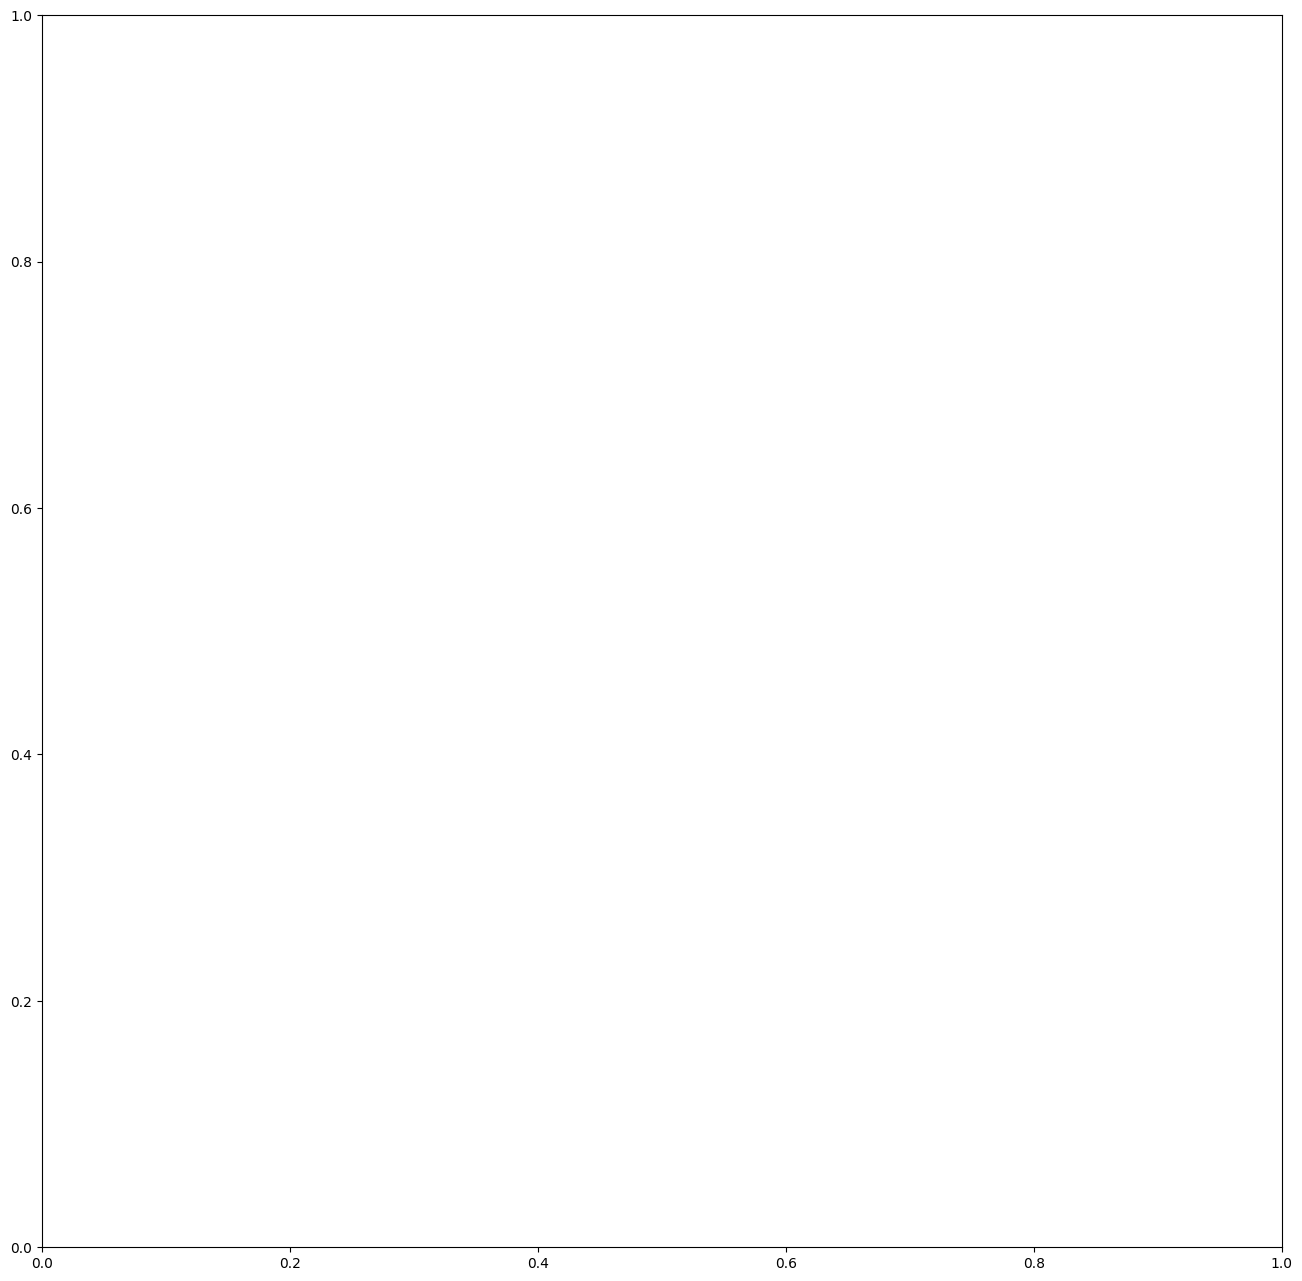

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
from adjustText import adjust_text
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(16, 16))

# Scatter plot of the topics
sns.scatterplot(
    ax=ax,
    data=df,
    x='x',
    y='y',
    hue='Topic',
    palette=color_key,
    alpha=0.4,
    sizes=(0.4, 10),
    size="Length"
)

# Annotate top 50 topics
texts, xs, ys = [], [], []
for _, row in mean_df.iterrows():
    topic = row["Topic"]
    name = " - ".join([word for word, _ in topic_model.get_topic(int(topic))][:3])

    xs.append(row["x"])
    ys.append(row["y"])
    texts.append(ax.text(
        row["x"],
        row["y"],
        name,
        size=10,
        ha="center",
        color=color_key[topic],
        path_effects=[pe.withStroke(linewidth=0.5, foreground="black")]
    ))

# Adjust annotations such that they do not overlap
adjust_text(
    texts,
    x=xs,
    y=ys,
    ax=ax,
    time_lim=1,
    force_text=(0.01, 0.02),
    force_static=(0.01, 0.02),
    force_pull=(0.5, 0.5)
)

# Zoom in on the plot
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

# Save the plot
plt.savefig("visualization2.png", dpi=600)

# Display the plot
plt.show()



In [ ]:
plt.savefig("visualization2.png", dpi=600)

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
files.download("visualization2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Park**

In [ ]:
!pip install adjustText

In [ ]:
import itertools
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patheffects as pe

In [ ]:
df = pd.DataFrame({
    "x": reduced_embeddings_2d[:, 0],
    "y": reduced_embeddings_2d[:, 1],
    "Topic": [str(t) for t in topics]
})
df["Length"] = [len(doc) for doc in filtered_texts]
df = df.loc[df.Topic != "-1"]
df = df.loc[(df.y > -10) & (df.y < 10) & (df.x < 10) & (df.x > -10), :]
df["Topic"] = df["Topic"].astype("category")

# Get centroids of clusters
mean_df = df.groupby("Topic").mean().reset_index()
mean_df.Topic = mean_df.Topic.astype(int)
mean_df = mean_df.sort_values("Topic")

# Define colors for the visualization to iterate over
colors = itertools.cycle([
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4',
    '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff',
    '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1',
    '#000075', '#808080', '#ffffff', '#000000'
])
color_key = {str(topic): next(colors) for topic in set(topics) if topic != -1}

In [ ]:
fig = plt.figure(figsize=(16, 16))

# Scatter plot of the topics
sns.scatterplot(
    data=df,
    x='x',
    y='y',
    hue='Topic',
    palette=color_key,
    alpha=0.4,
    sizes=(0.4, 10),
    size="Length"
)

# Annotate top 50 topics
texts, xs, ys = [], [], []
for row in mean_df.iterrows():
    topic = row[1]["Topic"]
    name = " - ".join([word for word, _ in topic_model.get_topic(topic)][:3])

    if int(topic) <= 50:
        xs.append(row[1]["x"])
        ys.append(row[1]["y"])
        texts.append(plt.text(
            row[1]["x"],
            row[1]["y"],
            name,
            size=10,
            ha="center",
            color=color_key[str(topic)],
            path_effects=[pe.withStroke(linewidth=0.5, foreground="black")]
        ))

# Adjust annotations such that they do not overlap
adjust_text(
    texts,
    x=xs,
    y=ys,
    time_lim=1,
    force_text=(0.01, 0.02),
    force_static=(0.01, 0.02),
    force_pull=(0.5, 0.5)
)

plt.show()
# plt.savefig("visualization2.png", dpi=600)


In [ ]:
fig = topic_model.visualize_topics(); fig

In [ ]:
topic_model.visualize_hierarchy(top_n_topics=50) # Hierarchy

In [ ]:
topic_model.visualize_heatmap(n_clusters=10, width=1000, height=1000)

** Business **

In [ ]:
fig = topic_model.visualize_topics(); fig

In [ ]:
topic_model.visualize_hierarchy(top_n_topics=50) # Hierarchy

In [ ]:
topic_model.visualize_heatmap(n_clusters=10, width=1000, height=1000)

# Topics over time

**Park Reviews**

In [ ]:
# Data Preprocessing Function
def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation and not char.isdigit()])
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Apply preprocessing to clean the reviews
merged_data['Cleaned_Review'] = merged_data['Review'].apply(preprocess_text)

# Filtering and preparing park reviews
park_reviews = merged_data[merged_data['Park'] == 1]
park_reviews['Timestamp_park'] = park_reviews['Timestamp'].apply(lambda x: x.toordinal())

# Prepare lists for BERTopic
texts = park_reviews['Cleaned_Review'].tolist()
timestamps = park_reviews['Timestamp_park'].tolist()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
topic_model = BERTopic(embedding_model='all-MiniLM-L6-v2',
                       min_topic_size=5,
                       calculate_probabilities=True,
                       verbose=True)

# Train the BERTopic model
topics, probabilities = topic_model.fit_transform(texts)

2024-05-16 21:41:51,339 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

2024-05-16 21:42:00,426 - BERTopic - Embedding - Completed ✓
2024-05-16 21:42:00,428 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-05-16 21:42:15,130 - BERTopic - Dimensionality - Completed ✓
2024-05-16 21:42:15,132 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-05-16 21:42:15,315 - BERTopic - Cluster - Completed ✓
2024-05-16 21:42:15,321 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-05-16 21:42:15,423 - BERTopic - Representation - Completed ✓


In [ ]:
try:
    topics_over_time = topic_model.topics_over_time(docs=texts,
                                                    topics=topics,
                                                    timestamps=timestamps,  # Here we use timestamps
                                                    global_tuning=True,
                                                    evolution_tuning=True,
                                                    nr_bins=20)
    # Optionally, visualize the topics over time
    topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5)
except Exception as e:
    print("An error occurred:", e)

20it [00:00, 35.04it/s]


In [ ]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5)

**Business Reviews**

In [ ]:
try:
    topics_over_time = topic_model.topics_over_time(docs=texts,
                                                    topics=topics,
                                                    timestamps=timestamps,
                                                    global_tuning=True,
                                                    evolution_tuning=True,
                                                    nr_bins=20)
    # Optionally, visualize the topics over time
    topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5)
except Exception as e:
    print("An error occurred:", e)

19it [00:05,  3.19it/s]


In [ ]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5)

**全部趋势**

In [ ]:
topics_over_time = topic_model.topics_over_time(docs=data['Cleaned_Review'],
                                                topics=topics,
                                                timestamps=data['Timestamp_orginal_format'],
                                                global_tuning=True,
                                                evolution_tuning=True,
                                                nr_bins=20)

19it [00:05,  3.42it/s]


In [ ]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=200)

# Assign topics and probabilities to Park and Business Reviews

**park**

In [ ]:
park_reviews['Topic'] = topics
park_reviews['Probabilities'] = probabilities.tolist()

In [ ]:
# !!这个是选20个最关联 并且 频率最高的
# 暂时废弃
topic_info = topic_model.get_topic_info()
top_20_topics = topic_info.iloc[1:21]['Topic'].tolist()

park_reviews = park_reviews[park_reviews['Topic'].isin(top_20_topics)]

In [ ]:
# Drop the the columns with topic -1
park_reviews = park_reviews[park_reviews['Topic'] != -1]

In [ ]:
prob_df = pd.DataFrame(park_reviews['Probabilities'].to_list(), index=park_reviews.index)
prob_df.columns = [f'Topic_{i}_Probability' for i in prob_df.columns]
park_reviews = pd.concat([park_reviews, prob_df], axis=1)
park_reviews.drop(columns=['Probabilities'], inplace=True)

In [ ]:
output_file_path = ''
park_reviews.to_csv(output_file_path, index=False)

In [ ]:
# 搞一个file看看park里面的topics都代表什么
topic_info = topic_model.get_topic_info()
topics_representation = {topic: topic_model.get_topic(topic) for topic in topic_info.Topic if topic != -1}

topics_df = pd.DataFrame([(topic, word, weight) for topic, words in topics_representation.items() for word, weight in words],
                         columns=['Topic', 'Word', 'Weight'])

In [ ]:
topics_representation_file_path = ''
topics_df.to_csv(topics_representation_file_path, index=False)